In [1]:
# ── Imports ──
# Riley Greene V1 — same architecture as Witt V10
# 8 features: era, park_factor, pitcher_r, is_home,
#             avg_exit_velo_15, barrel_rate_15, hard_hit_rate_15, hr_zone_rate_15
# Key differences:
#   - Greene bats LEFT — pitcher_r expected > 1 (platoon advantage vs RHP)
#   - Comerica Park (team_id 116) — park factor 105, favorable for lefty pull hitters
#   - 4 seasons of data (2022 partial, 2023 injury year, 2024, 2025)
#   - 2023 injury year (11 HRs, 99 games) may drag base rate down — watch HR distribution
#   - High K rate (30.7% in 2025) — potential Schwarber-style collinearity risk
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [2]:
# ── Load base dataset from database ──
# Riley Greene player_id = 682985
PLAYER_ID = 682985

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 116
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (497, 12)
         date  hr  tb   era
0  2022-06-18   0   2  5.37
1  2022-06-19   0   0  4.04
2  2022-06-20   0   1  4.50
3  2022-06-21   0   2  4.25
4  2022-06-22   0   1  2.28
5  2022-06-24   0   1  3.46
6  2022-06-25   0   0  3.96
7  2022-06-26   0   0  7.88
8  2022-06-28   0   3  2.70
9  2022-06-29   0   1  5.05


In [3]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt: 16.0%, Julio: 18.1% for comparison)")
print(f"Note: 2023 injury year (11 HR, 99 games) will drag this down")


HR distribution:
hr
0    428
1     62
2      7
Name: count, dtype: int64

Games with 0 HR:  0.861
Games with 1+ HR: 0.139 (13.9% of games)
Games with 2+ HR: 0.014

Break-even American odds: -16

(Witt: 16.0%, Julio: 18.1% for comparison)
Note: 2023 injury year (11 HR, 99 games) will drag this down


In [4]:
# ── Pull Statcast data via pybaseball ──
# Riley Greene player_id = 682985
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=682985)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (9385, 118)


In [5]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (528, 9)
    game_date  barrel_rate  hr_zone_rate
0  2022-04-01          0.5           0.5
1  2022-06-18          0.0           0.5
2  2022-06-19          0.0           0.0
3  2022-06-20          0.0           0.2
4  2022-06-21          0.0           0.0
5  2022-06-22          0.0           0.0
6  2022-06-24          0.0           0.0
7  2022-06-25          0.0           0.0
8  2022-06-26          0.0           0.0
9  2022-06-28          0.0           0.0


In [6]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2022-04-01             NaN              NaN
1   2022-06-18             NaN              NaN
2   2022-06-19             NaN              NaN
3   2022-06-20             NaN              NaN
4   2022-06-21             NaN              NaN
5   2022-06-22             NaN              NaN
6   2022-06-24             NaN              NaN
7   2022-06-25        0.071429         0.171429
8   2022-06-26        0.062500         0.150000
9   2022-06-28        0.055556         0.133333
10  2022-06-29        0.050000         0.120000
11  2022-07-01        0.058442         0.109091
12  2022-07-02        0.053571         0.100000
13  2022-07-03        0.087912         0.150000
14  2022-07-04        0.095918         0.153571
15  2022-07-05        0.094286         0.148095
16  2022-07-06        0.072063         0.136984
17  2022-07-07        0.072063         0.111058
18  2022-07-08        0.072063         0.111058
19  2022-07-09        0.072063         0

In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (497, 17)
avg_exit_velo_15    20
barrel_rate_15      20
hr_zone_rate_15     20
dtype: int64


In [8]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Greene bats left — pitcher_r expected > 1 (platoon advantage vs RHP)
# Comerica park factor 105 — favorable, especially for lefty pull hitters

# Drop rows missing Statcast rolling features only
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (477, 19)


In [9]:
# ── Define features and binary target ──
# Greene V1 — 8 features, no k_per_9 to start
# Will add k_per_9 in V2 only if signs are clean
# High K rate (30.7%) suggests possible Schwarber-style insensitivity to pitcher K/9
FEATURES = [
    # Greene contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    'pitcher_r',
    # Pitcher
    'era',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt: 0.160, Julio: 0.181 for comparison)")


Features: 8
Dataset: (477, 8)
HR rate: 0.145 (69 HR games out of 477)

(Witt: 0.160, Julio: 0.181 for comparison)


In [10]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [11]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.855
Break-even odds for HR prop: -17


In [12]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

Best C:        0.05
Best CV AUC:   0.591

 param_C  mean_test_score  std_test_score
   0.001           0.5853          0.0242
   0.010           0.5841          0.0219
   0.050           0.5909          0.0205
   0.100           0.5893          0.0154
   0.250           0.5867          0.0138
   0.500           0.5859          0.0150
   1.000           0.5840          0.0150
   2.000           0.5838          0.0141
   5.000           0.5834          0.0142
  10.000           0.5821          0.0148


In [13]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nGreene V1 CV AUC:  {cv_auc.mean():.3f}")
print(f"Witt V10 CV AUC:   0.567")
print(f"Julio V1 CV AUC:   0.555")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(0.629), np.float64(0.597), np.float64(0.573), np.float64(0.578), np.float64(0.577)]
CV ACC per fold:  [np.float64(0.886), np.float64(0.861), np.float64(0.848), np.float64(0.823), np.float64(0.772)]

AUC mean +/- std: 0.591 +/- 0.021
ACC mean +/- std: 0.838 +/- 0.039

Baseline ACC:     0.855
Improvement:      -0.017

Greene V1 CV AUC:  0.591
Witt V10 CV AUC:   0.567
Julio V1 CV AUC:   0.555

(AUC > 0.55 = meaningful signal for sports betting)


In [14]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.638
In-sample ACC:  0.855
CV AUC:         0.591

Gap (in-sample - CV AUC): 0.047
(smaller gap = less overfitting)

Mean P(HR):     0.145
Actual HR rate: 0.145


In [15]:
# ── Calibration table ──
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V6 spread:              0.185")
print(f"V5 spread:              ~0.12")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate   n
pred_bin                                 
0                  0.083        0.073  96
1                  0.128        0.095  95
2                  0.146        0.158  95
3                  0.165        0.179  95
4                  0.201        0.219  96

Spread (bin 4 - bin 0): 0.146
V6 spread:              0.185
V5 spread:              ~0.12

(larger spread = better discrimination between HR and non-HR games)


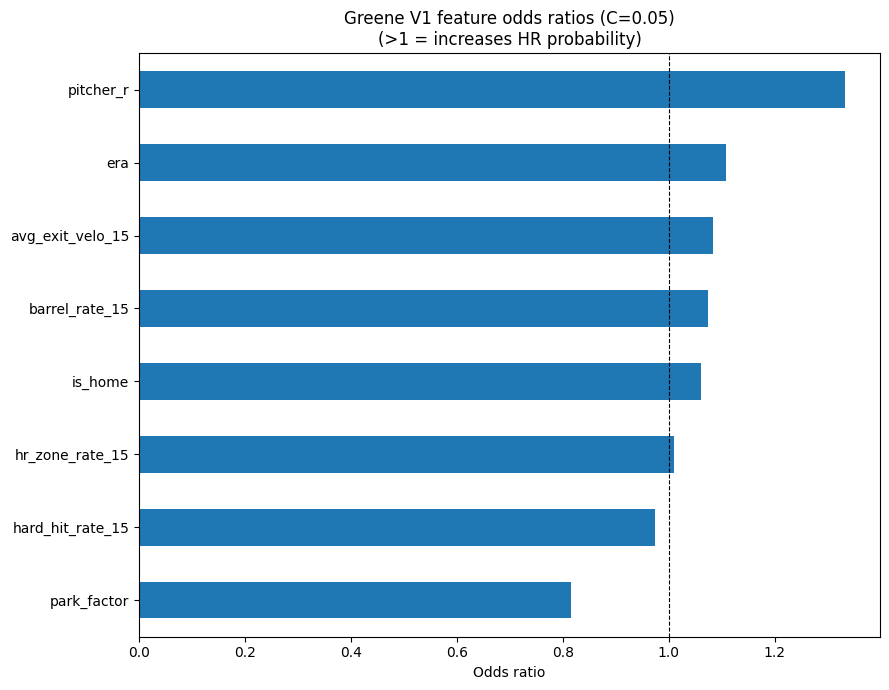


Odds ratios:
park_factor         0.816
hard_hit_rate_15    0.973
hr_zone_rate_15     1.009
is_home             1.062
barrel_rate_15      1.074
avg_exit_velo_15    1.084
era                 1.108
pitcher_r           1.332
dtype: float64


In [16]:
# ── Feature odds ratios ──
# Expected directions:
#   era        > 1 — higher ERA = worse pitcher = more HRs
#   park_factor > 1 — Comerica 105, favorable HR park
#   pitcher_r  > 1 — Greene bats left, platoon advantage vs RHP
#   is_home    > 1 — home field at Comerica
#   Statcast   uncertain — high K rate may mean hot streaks don't persist
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Greene V1 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [17]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
457 2025-09-05  0.166648           500  ❌ No HR
458 2025-09-06  0.081002          1135  ❌ No HR
459 2025-09-07  0.164724           507  ❌ No HR
460 2025-09-09  0.186998           435  ❌ No HR
461 2025-09-10  0.093628           968     ✅ HR
462 2025-09-11  0.169083           491  ❌ No HR
463 2025-09-12  0.201108           397     ✅ HR
464 2025-09-13  0.196355           409  ❌ No HR
465 2025-09-14  0.208551           379  ❌ No HR
466 2025-09-16  0.073431          1262  ❌ No HR
467 2025-09-17  0.132928           652  ❌ No HR
468 2025-09-18  0.138854           620  ❌ No HR
469 2025-09-19  0.142661           601  ❌ No HR
470 2025-09-20  0.074613          1240  ❌ No HR
471 2025-09-21  0.135114           640  ❌ No HR
472 2025-09-23  0.172838           479     ✅ HR
473 2025-09-24  0.188802           430  ❌ No HR
474 2025-09-25  0.092414           982     ✅ HR
475 2025-09-26  0.072606          12

In [18]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/greene_hr_logistic_v1_model.pkl')
joblib.dump(scaler, '../models/greene_hr_logistic_v1_scaler.pkl')
print("Saved:")
print("  models/greene_hr_logistic_v1_model.pkl")
print("  models/greene_hr_logistic_v1_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/greene_hr_logistic_v1_model.pkl
  models/greene_hr_logistic_v1_scaler.pkl

Best C: 0.05
Features (8): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'park_factor']
